# Week 5: TCSS600 - Independent Study Credit in Machine Learning

#### Before we dive into this week's learning objectives, let's circle back to Professor Ankur's Week4 email.  In it, he challenged me to review other 'generative' classification models like Naive Bayes and how one can use TF-IDF and Naive Bayes for applications like spam filtering.  Let's take a moment to review these concepts and then run a CHAT-GPT guided exercise as an example.  We will have to define a few concepts and build up to the code.  

#### Naive Bayes - The Naive Bayes classifier is a probabilistic machine learning model used for text classification and other tasks with discrete features (like word counts).  In python, we can implement it using NultinomialNB.  "Multinomial" refers to the multinomial distribution, which models the probability of a sequence of discrete outcomes (like words in text).  "Naive" treats the language like it's just a bag of full of words and each message is a random handful of them.  This assumes all features (words) are independent given the class label.  Bayes' Theorem computes P(Class | Words) ∝ P(Words | Class) × P(Class), then picks the class with the highest probability. 

#### TF-IDF - This term stands for "Term Frequency (TF) X Inverse Document Frequency (IDF)."  Term frequency is how often a word appears in the documents.  Inverse Document Frequency is how rare the word is across all documents (rarer = more important = larger value).  So a common word like "the" will get downweighted, while a rare but meaningful word like "offer" in spam gets boosted.  We can implement TF-IDF in python using TfidfVectorizer which outputs a sparse matrix of TF-IDF scores, with rows as documents and columns as vocabulary words.     

#### We can implement these two together using "make_pipeline" in python.  This creates a pipeline of steps where the output of one component automatically feeds into the next.  "make_pipeline" automates the fit, transformation, and prediction.  Now we can fit them all together: 

In [7]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

# Example dataset
texts = [
    "Buy cheap meds now",      # spam
    "Limited time offer",      # spam
    "Meeting at 10am",         # not spam
    "Lunch schedule updated",  # not spam
]

labels = [1, 1, 0, 0]  # 1 = spam, 0 = not spam

# Build model pipeline
model = make_pipeline(TfidfVectorizer(), MultinomialNB())

# Train the model
model.fit(texts, labels)

# Try it on a new message
test_message = "cheap meds offer just for you"
predicted = model.predict([test_message])

print("Spam" if predicted[0] == 1 else "Not Spam")


Spam


## <u>So what idea is Professor Ankur trying to reinforce?</u>

#### Professor Ankur wants to demonstrate that before attention mechanisms (which power transformers and large language models), simpler statistical methods like TF-IDF and Naïve Bayes were the state-of-the-art for natural language tasks like spam filtering or document classification.  Our simple model doesn't use attention- but it "attends" to word frequencies and rareness in the document in order to understand what the document represents.  This exercise is to build intuition around the concept of 'attention' and to better appreciate how transformative the concept of attention is.    

# Week5 Learning Objectives (from study plan)

#### In Week 5 I will begin coding the overall LLM architecture.  This includes layer normalization, activation functions, feed forward networks, shortcut connections, and adding them together in the final transformer block.  The GPT model I intend to code will have 12 repetitions of the transformer block for a total of 124-million total trainable weights.  Chapter 4 walks readers through building methods for each component of the transformer block with exercises on initializing them with different variables.      

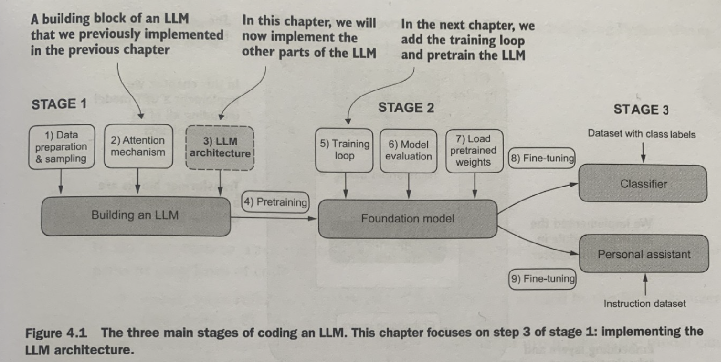

# (1) A GPT MODEL

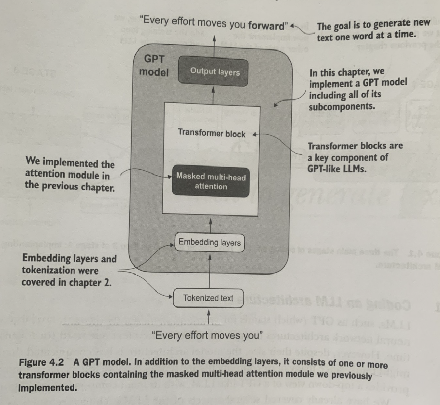

# GPT-2 vs. GPT-3

#### "Note that we are focusing on GPT-2 because OpenAI has made the weights of the pretrained model publicly available, which we will load into our implmentation in Chapter 6 (Week7).  GPT-3 is funadmentally the same in terms of model architechture, except that it is scaled up from 1.5 billion parameters in GPT-2 to 175 billion parameters in GPT-3, and it is trained on more data. (Note: A "parameter" in Raschka's textbook refers to a trainable weight.)  The weights for GPT-3 are not publicly available.  GPT-2 is also a better choice for learning how to implement LLMs because you can actually run it on a single laptop, whereas GPT-3 requires a GPU cluster for training and inference.  According to Lambda Labs, it would take 355 years to train GPT-3 on a single V100 datacenter GPU and 655 years on a consumer RTX 8000 GPU."

In [19]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

#### This is the configuration of a small GPT-2 Model with only 124 million parameters. 

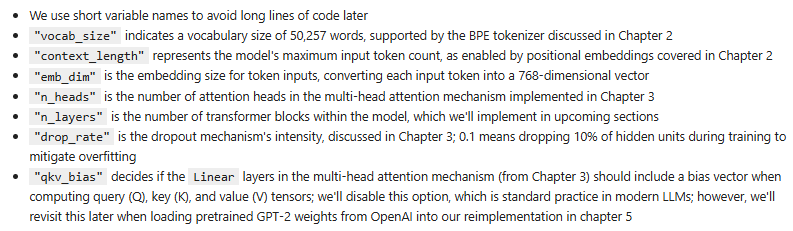

#### Yay!  All of these terms make sense.  Here are the steps we have to follow to cover the GPT Architechture in this chapter: 

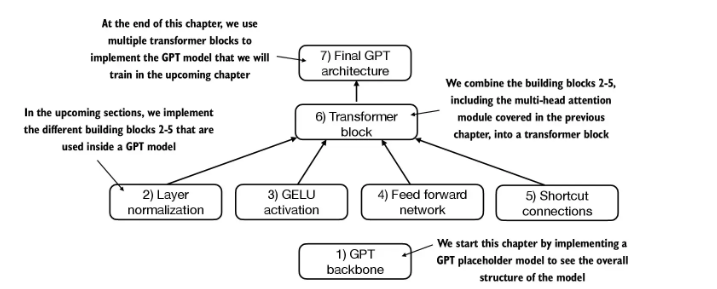

#### Here is a placeholder for a GPT model architecture class:

In [20]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

#### Let's consider a high level overview of how data flows in and out of a GPT model.  Start by tokenizing a batch consisting of two text inputs:  

In [21]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


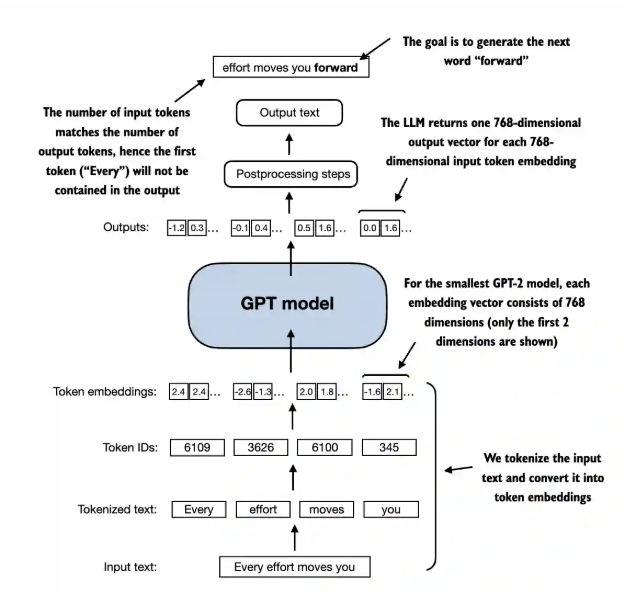

In [22]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)


#### "The output tensor has two rows corresponding to the two text samples.  Each text sample consists of four tokens; each token is a 50,257-dimensional vector, which matches the size of the tokenizer's vocabulary.  The embedding has 50,257 dimensions because each of these dimensions refers to a unique token in the vocabulary.  When we implement the postprocessing code, we will convert these 50,257-dimensional vectors back into token IDs, which we can then decode into words."  

## (2) Layer Normalization

#### The main idea behind layer normalization is to adjust the activations (outputs) of a neural network layer to have a mean of 0 and a variance of 1, also known as unit variance.  We typically apply this before and after the multi-head attention module. 

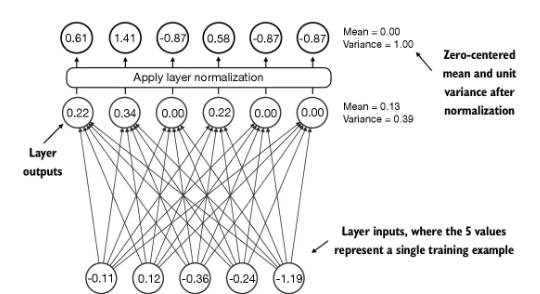

#### We can recreate the aboce example with the following example code, where we implement a neural networ layer with five inputs and six outputs that we apply to the two input examples:

In [23]:
torch.manual_seed(123)

# create 2 training examples with 5 dimensions (features) each
batch_example = torch.randn(2, 5) 

layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


#### The neural network layer we have coded consists of a Linear layer followed by a non-linear activation fucntion, ReLU, which is a standard activation function in neural networks.  Remember that ReLU thresholds negative inputs to 0, ensuring a layer only outputs positive values.  We studied this in Week1 and Week2.  Here is a picture from the ML textbook:

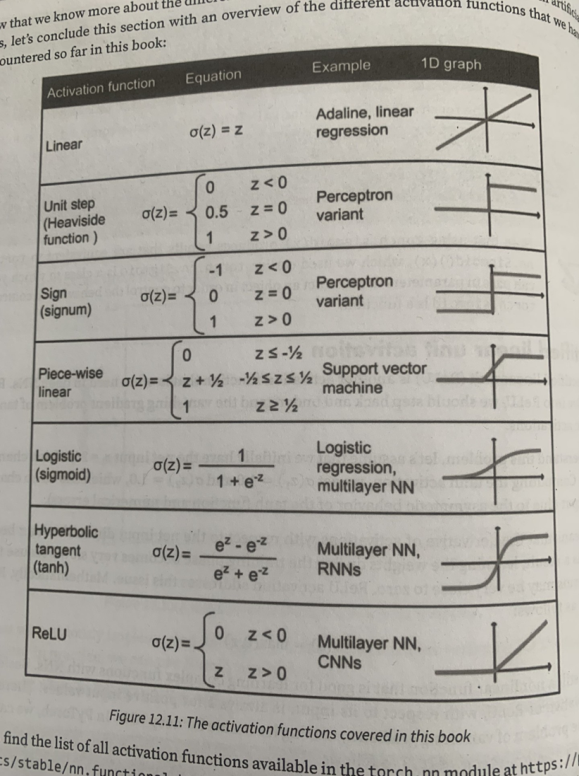

In [14]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


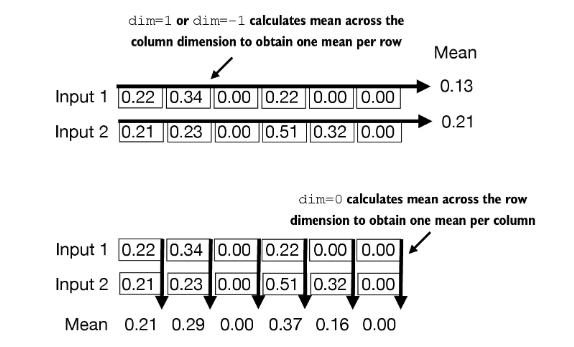

#### Let's apply layer normalization to the layer outputs we obtained earlier:

In [15]:
out_norm = (out - mean) / torch.sqrt(var)
print("Normalized layer outputs:\n", out_norm)

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


#### With this in tow, let's implement a layer normalization class:

In [16]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

#### Note that in addition to performing the normalization by subtracting the mean and dividing by the variance, we added two trainable parameters, a scale and a shift parameter.  The initial scale (multiplying by 1) and shift (adding 0) values don't have any effect; however, scale and shift are trainable parameters that the LLM automatically adjusts during training if it is determined that doing so would improve the model's performance on its training task.  Note that we also add a smaller value (eps) before computing the square root of the variance; this is to avoid division-by-zero errors if the variance is 0.   

In [17]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)

In [18]:
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-2.9802e-08],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


## <span style="color: purple"> Uhhhhhh, what was the point of all this again? </span> 

#### <span style="color: purple">Layer normalization improves the stability and efficiency of neural network training.  The adjustment speeds up the convergence to effective weights and ensures consistent, reliable training.</span> 

# (3) Implementing a Feed Forward Network with GELU activations

#### The GELU (Gaussian Error Linear Unit) is a more complex and smooth activation function incorporating Gaussian and sigmoid-gated linear units.  It offers superior performance for deep learning models, unlike the simpler RELU.  You can look at these images of GELU next to RELU and imagine which one is going to be easier for determining gradients.  

#### <span style="color: purple">"GELU allows for a small, non-zero output for negative values.  This characteristic means that during the training process, neurons that receive negative input can still contribute to the learning process, albeit to a lesser extent than positive inputs. </span>   

In [24]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

In [26]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 42.7 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 22.0 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]


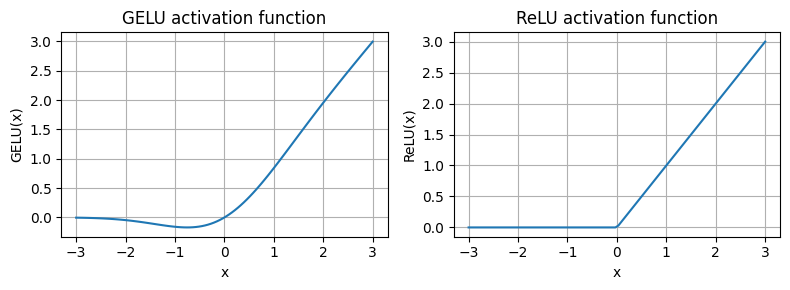

In [27]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# Some sample data
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

## Implementation of the GELU activation function

In [28]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

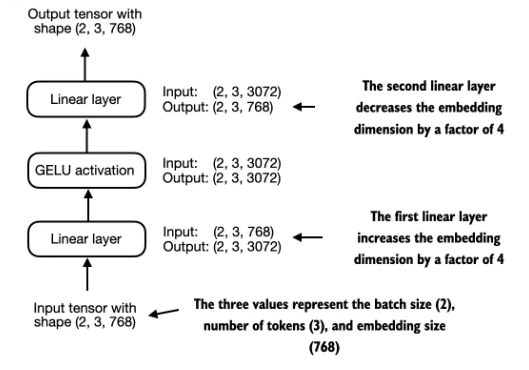

#### Examine how the linear layer increases the embedding dimension by a factor of 4.
####  Analogy:
#### Imagine summarizing a book:

#### First, you expand your thoughts into a full explanation (3072).

#### Then, you condense it into a sharp summary (768).

#### That’s what the FFN with 4× expansion does for embeddings.

# (4) Adding Shortcut Connections

#### Shortcut connections were proposed in deep networks for computer vision (residual networks) to mitigate vanishing gradient problems.
#### A shortcut connection creates an alternative shorter path for the gradient to flow through the network.

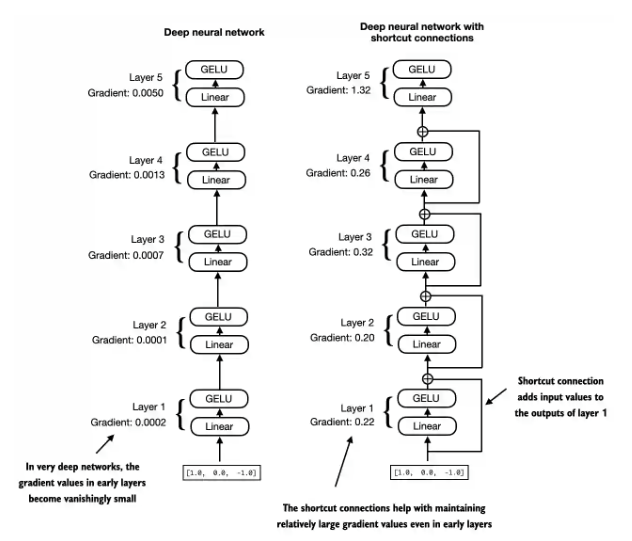

#### The book runs through an example of adding shortcut connections.  You essentially build TWO five layer neural networks, one with shortcuts and one without.  The exercise then calculates gradients, and surprise!  Using shortcut connections allows the gradient to stabilize at lower layers.  This overcomes the limitations posed by the vanishing gradient problem.  It's pretty simple, and you can get the same effect just by looking at the picture above.   

# (5) Connecting Attention and Linear Layers in a Transformer Block

#### "The transformer block, which is repeated a dozen times in the 124-million-parameter GPT-2 architecture, combines several concepts we have previously covered: multi-head attention, layer normalization, dropout, feed forwrd layers, and GELU activations...
#### "When a transformer block processes an input sequence, each element in the sequence (i.e. token) is represented by a fixed-size vector (768 dimensions).  The operations within the transformer block preserves their dimensionality...
#### "Self-attention mechanisms in the multi-head attention block identify and analyze relationships between elements in the input sequence.  The feed forward network modifies the data individually at each position...

#### <span style="color: purple">"Analogy- Attention = Group discussion — each token listens to all others and gathers info. FFN = Personal reflection — each token digests what it heard individually using the same mental process (the same weights).</span>  

#### One explanation I liked is that while the attention mechanism achieves a higher contextual understanding of the embedding, the linear layer (a) transforms and projects into a greater dimensional space, allowing for the learning of complex combinations and (b) uses GELU to apply nonlinear squashing - preverve the large values and shrink the small ones (smoothly)

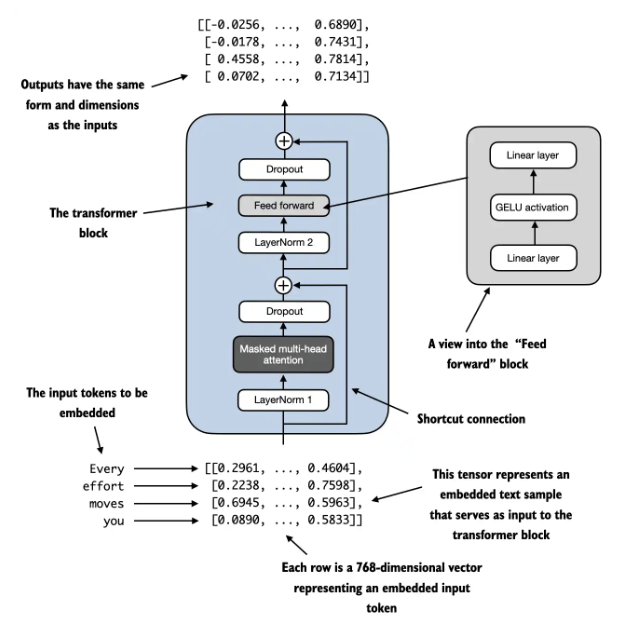

# To build the transformer block, we will first import MultiHeadAttention from last week's jupyter notebook.  I went ahead and converted it to a .py file in command terminal, so we should be able to import the class from Week4.py.

In [41]:
from Week4 import MultiHeadAttention

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

# (6) Coding the GPT Model 

#### We are now going to replace the DummyTransformerBlock and DummyLayerNorm placeholders in the DummyGPTModel.  

#### <span style="color: purple">"... In the case of the 124-million-parameter GPT-2 model, the transfomer block is repeated 12 times, which we specify via the n_layers entry in the GPT_CONFIG_124M dictionary.  This transform block is repeated 48 times in the largest GPT-2 model with 1,542 million parameters...  The output from the final transformer block then goes through a final layer normalization step before reaching the linear output layer.  This layer maps the transformer's output to a high-dimensional space (in this case, 50,257 dimensions, corresponding to the model's vocabulary size) to predict the next token in the sequence..."</span> 

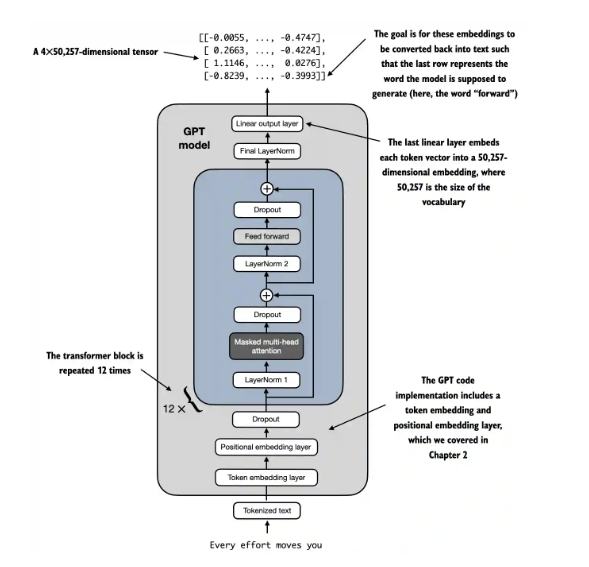

In [35]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

#### Using the configuration of the 124M parameter model, we can now instantiate this GPT model with random initial weights as follows

In [36]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.1381,  0.0077, -0.1963,  ..., -0.0222, -0.1060,  0.1717],
         [ 0.3865, -0.8408, -0.6564,  ..., -0.5163,  0.2369, -0.3357],
         [ 0.6989, -0.1829, -0.1631,  ...,  0.1472, -0.6504, -0.0056],
         [-0.4290,  0.1669, -0.1258,  ...,  1.1579,  0.5303, -0.5549]],

        [[ 0.1094, -0.2894, -0.1467,  ..., -0.0557,  0.2911, -0.2824],
         [ 0.0882, -0.3552, -0.3527,  ...,  1.2930,  0.0053,  0.1898],
         [ 0.6091,  0.4702, -0.4094,  ...,  0.7688,  0.3787, -0.1974],
         [-0.0612, -0.0737,  0.4751,  ...,  1.2463, -0.3834,  0.0609]]],
       grad_fn=<UnsafeViewBackward0>)


#### As we can see, the output tensor has the shape [2,4,50257] since we passed in two input texts with four tokens each.  The last dimension, 50257, corresponds to the vocabulary size of the tokenizer.  Later we will convert each of these 50,257 dimensional output vectors back into tokens.  

## Exercise 4.1 - Calcualate the number of parameters in the feed forward module and the attention module:

In [45]:
ff_model = FeedForward(GPT_CONFIG_124M)
total_params = sum(p.numel() for p in ff_model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 4,722,432


In [46]:
t_block = TransformerBlock(GPT_CONFIG_124M)
total_params = sum(p.numel() for p in t_block.att.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 2,360,064


## Of note, the entire model is approximately 621.83 MB.

## Exercise 4.2 - Use the GPTModel class to implement GPT-2 Medium. (1,024 dimensional embeddings, 24 transformer blocks, and 16 attention heads)

In [47]:
GPT_CONFIG_124M_Medium = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 1024,        # Embedding dimension
    "n_heads": 16,          # Number of attention heads
    "n_layers": 24,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}
model = GPTModel(GPT_CONFIG_124M_Medium)

# (7) Generating Text

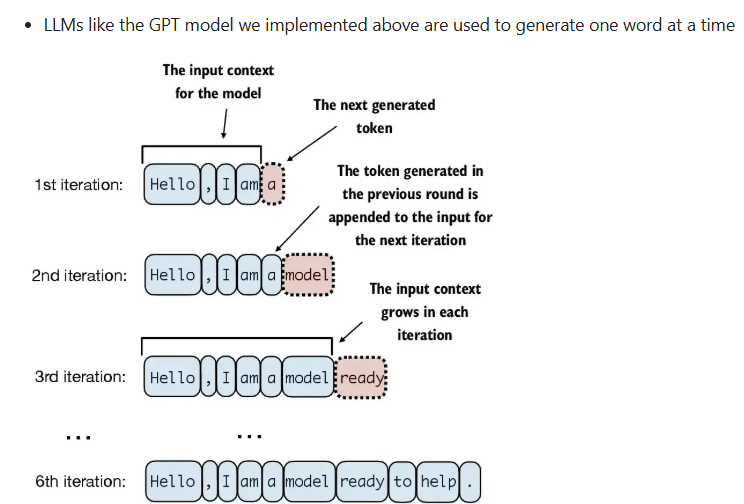

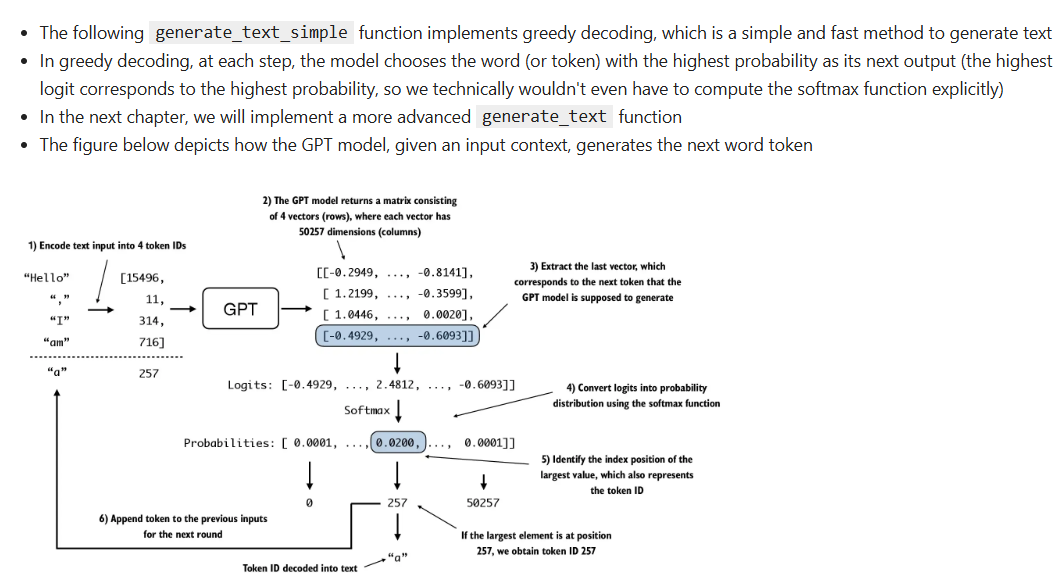

In [48]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):
        
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]
        
        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]  

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

#### <span style="color: purple">Note to self: the author is transforming logits to probabilities so the model can generate the next most likely token.  However, this is called "greedy decoding."  In the next chapter, the model won't select the most likely token.  This is supposed to introduce variablility and creativity in the generated text.  I am curious because what other approach is there BESIDES a "greedy" algorithm?</span> 

## Let's try out the simple generate text function-

In [49]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [50]:
model.eval() # disable dropout

out = generate_text_simple(
    model=model,
    idx=encoded_tensor, 
    max_new_tokens=6, 
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 37977, 36472, 23984, 17607, 44023, 17007]])
Output length: 10


In [51]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am TIT Export"></ fliesdepending mim


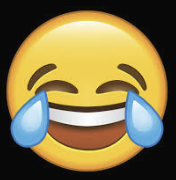

#### The model isn't trained so it spits out gibberish. 

## Exercise 4.3 Using seperate dropout parameters.  At the beginning of chapter 4, we defined a global drop_rate setting in the GPT_CONFIG_124M dictionary to set the dropout rate in various places throughout the GPTModel architechture.  Change the code to specify a seperate dropout value for the various dropout layers throughout the model architechture.  (Note: We use dropout layers in the embedding layer, shortcut layer, and multi-head attention model.)  Just for fun, rerun the generate text script and see if it changes anything. 

In [55]:
class TransformerBlock_43(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=0.2,
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(.2)

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

class GPTModel_43(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(.15)
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock_43(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

model_43 = GPTModel(GPT_CONFIG_124M)

In [58]:
#model_43.eval() # disable dropout

out = generate_text_simple(
    model=model_43,
    idx=encoded_tensor, 
    max_new_tokens=6, 
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 19443, 36875, 25675, 41809, 24137, 27689]])
Output length: 10


In [59]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am CoffeeReply browseSTER224 zeal
